In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
br=pd.read_csv(r"C:\Users\alpan\Downloads\blackrock.csv")

In [4]:
br

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,17-07-2023,47387.11457,2980.571037,0.780701,784,170
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,13-01-2023,55806.54015,27996.690070,0.299268,336,197
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,28-09-2023,51080.47837,81482.156180,0.388445,712,95
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,05-02-2023,70472.70472,39598.371940,0.561809,414,168
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,19-11-2023,29830.48767,111731.993700,0.655635,391,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,191,CUST9535,ACC70314,Loan,Deposit,Mutual Fund,Firm B,Central,Manager 3,02-03-2024,109333.69330,52127.585430,0.507608,359,60
796,180,CUST9420,ACC90887,Savings,Deposit,Credit Card,Firm D,West,Manager 4,12-02-2023,49898.56699,86055.045270,0.530922,552,179
797,41,CUST2349,ACC61827,Loan,Withdrawal,Credit Card,Firm C,South,Manager 1,04-02-2024,70111.40863,62017.827640,0.410514,609,159
798,184,CUST9564,ACC34568,Loan,Payment,Home Loan,Firm E,East,Manager 2,14-04-2023,30854.24614,17090.741810,0.553200,727,78


In [5]:
br.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


## Task 1: Data Cleaning and Formatting 

### Task 1.1: Remove/treat any special characters or non-numeric entries from financial fields. 

In [6]:
categorical_columns= br.dtypes[br.dtypes=='object'].index
categorical_columns

Index(['CustomerID', 'AccountID', 'AccountType', 'TransactionType', 'Product',
       'Firm', 'Region', 'Manager', 'TransactionDate'],
      dtype='object')

In [7]:
numerical_columns= br.dtypes[(br.dtypes=='int64') | (br.dtypes=='float64')].index
numerical_columns

Index(['TransactionID', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

#### --> no finanacial columns containa any special charaters or non numerical values 

### Task 1.2: Convert currency amounts into numerical format. 

In [8]:
br["TransactionAmount"]= pd.to_numeric(br["TransactionAmount"],errors='coerce')

In [9]:
br["AccountBalance"]= pd.to_numeric(br["AccountBalance"],errors='coerce')

In [10]:
br.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


### Task 1.3:  Validate and format date columns. 

In [11]:
br["TransactionDate"] = pd.to_datetime(br["TransactionDate"], dayfirst = True)

In [12]:
br.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

### Task 1.4 Ensure account types and transaction categories are standardized.

#### --> Account types and transaction categories are in standarized names.

In [13]:
br['AccountType'].unique().sum()

'CreditCurrentLoanSavings'

In [14]:
br['TransactionType'].unique().sum()

'WithdrawalPaymentDepositTransfer'

# Task 2: Descriptive Transactional Analysis

### Task 2.1: Calculate monthly and yearly summaries of total credits, debits, and net transaction volume. 

In [15]:
br['TransactionType'].value_counts()

TransactionType
Withdrawal    214
Transfer      208
Payment       196
Deposit       182
Name: count, dtype: int64

#### --> Total Credits = sum of Transaction Amount - Deposited (Transaction Type)

#### --> Total Debits = sum of Transaction amount of Withdrawal, Transfer and Payments done (Transaction Type)

In [16]:
br['Total_debits']=br['TransactionAmount'].where(br['TransactionType'].isin(['Withdrawal','Transfer','Payment']),0)

In [17]:
round(br['Total_debits'].sum(),2)

np.float64(32856407.47)

In [18]:
br['Total_credits']=br['TransactionAmount'].where(br['TransactionType']=='Deposit',0)

In [19]:
round(br['Total_credits'].sum(),2)

np.float64(10745085.9)

In [20]:
br['year']=br['TransactionDate'].dt.year
br['month']=br['TransactionDate'].dt.month
Transaction_summary = br.groupby(['year','month'])[['Total_credits','Total_debits']].sum()
Transaction_summary['Net_Transaction_Volume']=(Transaction_summary['Total_credits']-Transaction_summary['Total_debits'])
round(Transaction_summary)

Total_credits  Total_debits  Net_Transaction_Volume
year month                                                     
2023 1           453288.0     1778891.0              -1325603.0
     2           556591.0     2610104.0              -2053512.0
     3           405511.0     1913691.0              -1508180.0
     4           328958.0     1770646.0              -1441688.0
     5           933559.0     2341659.0              -1408100.0
     6           676082.0      989464.0               -313382.0
     7           486550.0     1422898.0               -936348.0
     8            81985.0     1933709.0              -1851724.0
     9           749147.0     2195770.0              -1446623.0
     10         1322052.0     2846267.0              -1524216.0
     11          966178.0     1984515.0              -1018337.0
     12          522862.0     1204102.0               -681240.0
2024 1           792453.0     1109510.0               -317057.0
     2           624446.0     2076592.0              -1452146.0
     3           765295.0     2623592.0              -1858297.0
     4           376351.0     1294163.0               -917812.0
     5           300787.0     1335151.0              -1034364.0
     6           402990.0     1425684.0              -1022694.0

### Task: 2.2 Plot Trends in total credits vs debits over time

#### --> balancechange is the difference Account balance occurs due to credit and debit in accounts

#### --> net_credit is the sum of balance where the account balance is more than 0.

#### --> net_debit is the sum of balance where the account balance is less than 0.

#### --> we plot the trend of total credit and debit over months not years

In [21]:
br['balancechange']= br['AccountBalance'].diff()
br['net_credit'] = br['AccountBalance'].where (br['balancechange']>0,0)
br['net_debit'] = br['AccountBalance'].where (br['balancechange']<0,0)

In [22]:
monthly_trend= br.groupby(br['TransactionDate'].dt.to_period('M'))[['net_credit','net_debit']].sum()

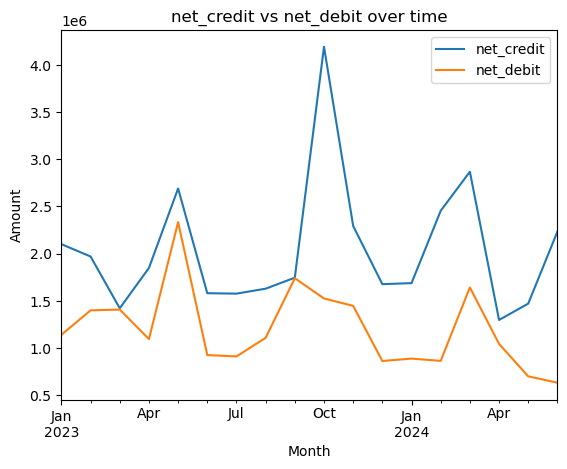

In [23]:
import matplotlib.pyplot as plt
monthly_trend.plot()
plt.title("net_credit vs net_debit over time")
plt.xlabel('Month')
plt.ylabel('Amount')
plt.show()

### Task: 2.3 Identify top and bottom performing accounts based on  net flow

In [24]:
Unique_account_detail= br.groupby('AccountID')[['net_credit','net_debit']].sum()
Unique_account_detail['net_flow'] = Unique_account_detail['net_credit']-Unique_account_detail['net_debit']

### 5 Top Performing Accounts based on net flow

In [25]:
top_performing_accounts = Unique_account_detail.sort_values(by='net_flow', ascending=False).head(5)

In [26]:
top_performing_accounts

,net_credit,net_debit,net_flow
AccountID,,,
ACC29231,612538.30982,0.00000,612538.30982
ACC28295,500173.23655,0.00000,500173.23655
ACC29646,507645.86480,23430.49327,484215.37153
ACC57700,510872.99761,69920.35629,440952.64132
ACC64022,387964.27030,-11356.97561,399321.24591


### 5 Bottom Performing Accounts based on net flow

In [27]:
bottom_performing_accounts = Unique_account_detail.sort_values(by='net_flow', ascending=True).head(5)

In [28]:
bottom_performing_accounts

,net_credit,net_debit,net_flow
AccountID,,,
ACC43771,80044.22591,393897.84694,-313853.62103
ACC78178,0.00000,292569.07038,-292569.07038
ACC95774,115204.97170,375083.88241,-259878.91071
ACC42467,0.00000,211164.60916,-211164.60916
ACC42903,0.00000,209012.95915,-209012.95915


### Task 2.4:  Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions. 

#### --> prev_transaction is the column which tells the previous transaction date of the same account ID thus we need to first sort the AccountID and then TransactionDate to get the correct difference of days between two transaction by the same account
#### --> gap_days calculates the total days between two transactions by the same account
#### --> account_status_flag is the column which flags the accounts which have 
#### --> gap of more than 60 days between two transactions as Inactive 
#### --> accounts with less than 60 gap days are Active

In [29]:
br=br.sort_values(['AccountID','TransactionDate'])
br['prev_transaction']= br.groupby('AccountID')['TransactionDate'].shift(1)
br['gap_days']=(br['TransactionDate']-br['prev_transaction']).dt.days
br['max_gap']= br.groupby('AccountID')['gap_days'].transform('max')
br['account_status']=br['max_gap'].apply(lambda x: 'Inactive' if x>=60 else'Active')
account_status_flag = br[['AccountID', 'account_status']].drop_duplicates()
account_status_flag['account_status'].value_counts()

account_status
Inactive    172
Active       20
Name: count, dtype: int64

#### --> Out of 192 unique accounts 172 accounts are inactive and 20 accounts are active.

# Task 3: Customer Profile Building

###  Task 3.1: Group Accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings. 

In [30]:
br['Total_Transactions'] = br.groupby('CustomerID')['TransactionID'].transform('count')
br['Total_Transactions'] 

549    3
301    5
724    5
787    2
27     6
      ..
398    5
336    4
303    6
139    6
581    7
Name: Total_Transactions, Length: 800, dtype: int64

#### --> We define a function to segment the Customers by activity level
#### --> If Total_Transactions >10  then Activity level marked as High
#### --> If Total_Transactions =>5 then Activity level marked as Medium
#### --> If Total_Transactions <5 then Activity level marked as Low

In [31]:
def activity_level(x):
    if x > 10:
        return"High"
    elif x>=5:
        return"Medium"
    else:
        return "Low"
br['activity_level'] =br['Total_Transactions'].apply(activity_level)
activity_level

<function __main__.activity_level(x)>

In [32]:
br[['CustomerID','activity_level']].drop_duplicates()['activity_level'].value_counts()

activity_level
Low       97
Medium    82
High       1
Name: count, dtype: int64

### --> Customer activity segementation : Customers were segmented into activity levels based on the number of transactions performed

### Task 3.2: Segment customers by average balance and transaction volume. 

In [33]:
avg_balance= br.groupby('CustomerID')['AccountBalance'].mean().reset_index(name='Avg_Balance')
transaction_volume = br.groupby('CustomerID')['TransactionID'].count().reset_index(name='Transaction_count')
customer_details=avg_balance.merge(transaction_volume, on = 'CustomerID')

#### Define a function to segment the customers based on different conditions 
#### --> If Average Balance is more than 20000 and Transaction count is more than 8 mark as Premium customer
#### --> If Average Balance is >= 20000 and Transaction count is >= 4 mark as Elite customer
#### --> If Average Balance is >= 5000 and Transaction count is >=2 mark as Basic customer
#### --> Else mark as New customer

In [34]:
def segment(data):
    if data['Avg_Balance'] >20000 and data['Transaction_count']>8:
        return"Premium"
    elif data['Avg_Balance'] >= 20000  and data['Transaction_count']>=4:
        return"Elite"
    elif data['Avg_Balance'] >= 5000 and data['Transaction_count']>=2:
        return"Basic"
    else:
        return "New"
customer_details['segment_customers']= customer_details.apply(segment , axis = 1)

In [35]:
customer_details.head(10)

,CustomerID,Avg_Balance,Transaction_count,segment_customers
0,CUST1042,79417.266317,6,Elite
1,CUST1114,51474.223220,2,Basic
2,CUST1121,63924.640954,5,Elite
3,CUST1189,39051.942297,3,Basic
4,CUST1223,76370.221527,7,Elite
5,CUST1376,80779.647074,5,Elite
6,CUST1467,56689.613536,5,Elite
7,CUST1497,90564.708385,4,Elite
8,CUST1498,65424.298341,8,Elite
9,CUST1547,92293.667688,6,Elite


In [36]:
customer_details['segment_customers'].value_counts()

segment_customers
Elite      109
Basic       56
New          8
Premium      7
Name: count, dtype: int64

### Task 3.3: Create profiles for: 
### Task 3.3.1: High-net inflow accounts

#### To get the top 5 High inflow accounts we find calculate the overall_net_inflow by AccountID 
#### then sort the values in descending order and extract only top 5 accounts with high inflow

In [37]:
overall_net_flow = br.groupby('AccountID')['AccountBalance'].sum().reset_index(name='net_flow')
net_inflow_accounts= overall_net_flow.sort_values(by='net_flow',ascending=False).head(5)
net_inflow_accounts

,AccountID,net_flow
77,ACC41829,801172.534718
13,ACC16241,764175.627330
3,ACC11188,722116.360500
188,ACC97411,715262.630650
75,ACC40939,659794.704480


In [38]:
net_inflow_accounts.describe()

,net_flow
count,5.000000
mean,732504.371536
std,53409.430730
min,659794.704480
25%,715262.630650
50%,722116.360500
75%,764175.627330
max,801172.534718


#### As we see minimum net_inflow_accounts value is 659794 and maximum value is 801172 and mean is 732504
#### --> Then we set a criteria to know the Accounts whose inflow is more than 700000

In [39]:
high_net_inflow_accounts =overall_net_flow[overall_net_flow['net_flow']>700000]
high_net_inflow_accounts

,AccountID,net_flow
3,ACC11188,722116.360500
13,ACC16241,764175.627330
77,ACC41829,801172.534718
188,ACC97411,715262.630650


#### --> So there are only 4 out of 192 accounts with high inflow value of more than 700000.

### Task 3.3.2: High-frequency low-balance accounts

#### --> We consider Account have High-Frequency when Total_Transactions is more than 8 
#### --> We consider Account have Low balance when AccountBalance is less than 50000

In [40]:
high_frq_low_bal_accounts = br[(br['Total_Transactions'] >= 8) & (br['AccountBalance'] < 50000)]
customer_profile_2=high_frq_low_bal_accounts[['AccountID','AccountBalance','Total_Transactions']]
customer_profile_2

,AccountID,AccountBalance,Total_Transactions
536,ACC24070,12642.433800,9
370,ACC28154,49832.094580,10
152,ACC35419,44328.268860,8
739,ACC45521,-18963.797190,8
157,ACC49140,37584.564060,11
345,ACC55729,46054.339790,8
713,ACC57516,49558.858580,9
380,ACC57700,22188.806360,8
740,ACC61827,49298.638660,9
435,ACC71938,23713.158170,9


#### --> 16 out of 192 accounts are High-frequency low- Balance accounts

### Task 3.3.3:  Accounts with negative or near-zero balances

In [41]:
br['AccountBalance'].median()

73006.75195

#### --> We considered Accounts which have Balance <= 10 are near_zero_bal_accounts

In [42]:
near_zero_bal_accounts= br[br['AccountBalance']<= 10]
customer_profile_3 =near_zero_bal_accounts[['AccountID', 'AccountBalance']]
customer_profile_3.describe()
customer_profile_3

,AccountID,AccountBalance
7,ACC11062,-9084.224009
511,ACC15671,-8225.602340
442,ACC22036,-4547.371459
402,ACC30787,-3069.411127
642,ACC34821,-32532.523740
733,ACC39529,-35891.001750
389,ACC45101,-505.916206
739,ACC45521,-18963.797190
258,ACC46953,-26968.230900
432,ACC64022,-11356.975610


#### --> 18 out of 192 accounts have near or zero balance

# Task 4: Financial Risk Identification

### Task 4.1: Track accounts with frequent large withdrawals or overdrafts. 

In [43]:
Q1 = br['TransactionAmount'].quantile(0.25)
Q3 = br['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
overdrafts = br[(br['TransactionAmount'] < lower_bound) | 
              (br['TransactionAmount'] > upper_bound)]
overdrafts[['AccountID','TransactionAmount']]
overdrafts

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,month,balancechange,net_credit,net_debit,prev_transaction,gap_days,max_gap,account_status,Total_Transactions,activity_level
264,133,CUST4780,ACC18057,Savings,Payment,Personal Loan,Firm D,Central,Manager 2,2023-11-25,...,11,-5175.82673,0.00000,96490.53597,2023-10-21,35.0,115.0,Inactive,7,Medium
168,141,CUST2443,ACC21719,Current,Deposit,Home Loan,Firm E,North,Manager 2,2023-06-18,...,6,43476.24652,67341.54606,0.00000,2023-04-14,65.0,135.0,Inactive,5,Medium
306,190,CUST6565,ACC41829,Loan,Payment,Home Loan,Firm B,Central,Manager 3,2024-03-12,...,3,-10071.45836,0.00000,50912.94989,2024-02-04,37.0,135.0,Inactive,4,Low
755,30,CUST1888,ACC45101,Credit,Payment,Savings Account,Firm A,Central,Manager 1,2023-04-19,...,4,70719.74755,110349.68130,0.00000,2023-02-10,68.0,90.0,Inactive,3,Low
377,189,CUST1042,ACC83848,Loan,Payment,Personal Loan,Firm B,West,Manager 1,2024-02-09,...,2,-60456.72974,0.00000,33255.85985,2024-01-17,23.0,152.0,Inactive,6,Medium
481,20,CUST7793,ACC88449,Current,Transfer,Credit Card,Firm D,North,Manager 4,2023-06-19,...,6,-39727.78812,0.00000,74606.26678,2023-05-26,24.0,159.0,Inactive,7,Medium
640,67,CUST1962,ACC94203,Savings,Deposit,Home Loan,Firm C,South,Manager 2,2024-06-07,...,6,54786.72209,101402.64670,0.00000,2023-09-06,275.0,275.0,Inactive,8,Medium


#### --> 7 out of 192 Accounts are having frequent large withdrawals or overdrafts.

### Task 4.2: Calculate balance volatility using standard deviation or coefficient of variation. 

In [44]:
br['AccountBalance'].describe()

count       800.000000
mean      72947.111696
std       34206.072059
min      -35891.001750
25%       51133.057895
50%       73006.751950
75%       94553.225110
max      171767.657800
Name: AccountBalance, dtype: float64

In [45]:
balance_volatility = br.groupby('AccountID')['AccountBalance'].std().reset_index(name='Balance_volatility')
balance_volatility['Balance_volatility'] =balance_volatility['Balance_volatility'].fillna(0)
round(balance_volatility,2).sort_values(by='Balance_volatility', ascending= False)

,AccountID,Balance_volatility
73,ACC39529,91165.11
89,ACC46953,88564.26
154,ACC78589,86423.15
183,ACC95164,70375.13
21,ACC20297,70164.03
...,...,...
100,ACC50817,0.00
127,ACC65545,0.00
151,ACC78089,0.00
147,ACC77533,0.00


#### --> Balance volatility measure the fluctuation in account balance over time. 
#### --> It was calculated using the standard deviation of account balances for each account.
#### --> Accounts with only one transaction resulted in 0, assuming no variability in balance.

### Task 4.3: Use IQR or z-score methods to detect anomalies.

In [46]:
Q1= br['AccountBalance'].quantile(0.25)
Q3= br['AccountBalance'].quantile(0.75)
IQR=Q3-Q1
lower_bound= Q1- 1.5*IQR
upper_bound= Q3+ 1.5*IQR
outliers = br[(br['AccountBalance']<lower_bound) |(br['AccountBalance']>upper_bound)]
outliers[['AccountID','AccountBalance']]
outliers

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,month,balancechange,net_credit,net_debit,prev_transaction,gap_days,max_gap,account_status,Total_Transactions,activity_level
444,15,CUST4769,ACC28295,Current,Withdrawal,Home Loan,Firm B,East,Manager 4,2023-08-18,...,8,59515.81660,163654.2509,0.00000,NaT,NaN,172.0,Inactive,6,Medium
117,97,CUST4780,ACC29646,Savings,Deposit,Savings Account,Firm D,North,Manager 4,2023-09-30,...,9,90972.72580,160302.7378,0.00000,2023-05-12,141.0,141.0,Inactive,7,Medium
642,170,CUST3315,ACC34821,Savings,Transfer,Credit Card,Firm E,West,Manager 3,2023-02-04,...,2,-105791.72504,0.0000,-32532.52374,NaT,NaN,88.0,Inactive,7,Medium
733,65,CUST6565,ACC39529,Savings,Withdrawal,Credit Card,Firm B,East,Manager 2,2023-02-05,...,2,-120726.24875,0.0000,-35891.00175,NaT,NaN,308.0,Inactive,4,Low
739,102,CUST1962,ACC45521,Savings,Withdrawal,Home Loan,Firm C,South,Manager 4,2023-10-22,...,10,-102666.21557,0.0000,-18963.79719,2023-10-22,0.0,187.0,Inactive,8,Medium
258,68,CUST9731,ACC46953,Loan,Payment,Credit Card,Firm A,West,Manager 3,2023-10-24,...,10,-40439.58785,0.0000,-26968.23090,2023-02-14,252.0,252.0,Inactive,5,Medium
352,101,CUST4346,ACC65545,Current,Payment,Mutual Fund,Firm D,North,Manager 2,2023-09-10,...,9,105665.76176,171767.6578,0.00000,NaT,NaN,NaN,Active,3,Low
559,161,CUST4684,ACC66086,Credit,Transfer,Savings Account,Firm C,South,Manager 1,2024-04-06,...,4,93496.75611,166720.4415,0.00000,2023-07-30,251.0,251.0,Inactive,9,Medium
349,88,CUST5705,ACC71426,Current,Deposit,Credit Card,Firm B,North,Manager 4,2023-05-24,...,5,88771.13072,162291.3509,0.00000,2023-02-04,109.0,243.0,Inactive,5,Medium
309,135,CUST6735,ACC76549,Loan,Payment,Mutual Fund,Firm B,East,Manager 2,2023-03-07,...,3,66256.33438,161174.8656,0.00000,2023-01-10,56.0,147.0,Inactive,3,Low


#### --> 12 Out of 192 Accounts have anomalies they are outliers, which means that some balance values for an account are unusually high or unusually low compared to the typical balances of that account.

### Task 4.4: Highlight customers with irregular or suspicious transaction behavior. 

#### --> Customers which are having transaction amount difference more than 100000 

In [47]:
br['prev_transaction_amount'] = br.groupby('CustomerID')['TransactionAmount'].shift(1)
br['Amount_change'] = br['TransactionAmount']-br['prev_transaction_amount']
suspicious_customers = br[br['Amount_change'] >100000]
suspicious_customers[['CustomerID','Amount_change']]

,CustomerID,Amount_change
306,CUST6565,104273.459670
344,CUST3041,126352.703240
277,CUST2612,106284.097400
578,CUST4438,127626.065880
435,CUST4684,102359.625056
22,CUST5500,107008.076827
377,CUST1042,144958.270128
53,CUST7793,107160.695740
632,CUST1962,124689.478770
689,CUST2412,105561.566280


#### --> 10 out of 180 Customers have suspecious change in bwtween two consecutive transaction amount.

#### --> Customers having gap days more than 365 irregular customers

In [48]:
irregular_customers = br[br['gap_days'] >365]
irregular_customers[['CustomerID','gap_days']]

,CustomerID,gap_days
436,CUST7933,380.0
702,CUST4780,368.0
362,CUST5121,394.0
246,CUST2871,435.0
211,CUST5253,403.0
424,CUST5916,389.0
113,CUST1888,378.0
76,CUST2443,387.0


#### --> 8 out of 180 Customers have gap days between two transactions more than 365 that is a year.

# Task 5: Visualisation

In [49]:
br.shape

(800, 30)

In [50]:
br.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 549 to 581
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            800 non-null    int64         
 1   CustomerID               800 non-null    object        
 2   AccountID                800 non-null    object        
 3   AccountType              800 non-null    object        
 4   TransactionType          800 non-null    object        
 5   Product                  800 non-null    object        
 6   Firm                     800 non-null    object        
 7   Region                   800 non-null    object        
 8   Manager                  800 non-null    object        
 9   TransactionDate          800 non-null    datetime64[ns]
 10  TransactionAmount        800 non-null    float64       
 11  AccountBalance           800 non-null    float64       
 12  RiskScore                800 non-null  

In [51]:
br.isnull().sum()

TransactionID                0
CustomerID                   0
AccountID                    0
AccountType                  0
TransactionType              0
Product                      0
Firm                         0
Region                       0
Manager                      0
TransactionDate              0
TransactionAmount            0
AccountBalance               0
RiskScore                    0
CreditRating                 0
TenureMonths                 0
Total_debits                 0
Total_credits                0
year                         0
month                        0
balancechange                1
net_credit                   0
net_debit                    0
prev_transaction           192
gap_days                   192
max_gap                      8
account_status               0
Total_Transactions           0
activity_level               0
prev_transaction_amount    180
Amount_change              180
dtype: int64

In [52]:
br.duplicated().sum()
br.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Total_debits', 'Total_credits', 'year',
       'month', 'balancechange', 'net_credit', 'net_debit', 'prev_transaction',
       'gap_days', 'max_gap', 'account_status', 'Total_Transactions',
       'activity_level', 'prev_transaction_amount', 'Amount_change'],
      dtype='object')

In [53]:
categorical_columns= br.dtypes[br.dtypes=='object'].index
categorical_columns

Index(['CustomerID', 'AccountID', 'AccountType', 'TransactionType', 'Product',
       'Firm', 'Region', 'Manager', 'account_status', 'activity_level'],
      dtype='object')

In [54]:
numerical_columns= br.dtypes[(br.dtypes=='int64') | (br.dtypes=='float64')].index
numerical_columns

Index(['TransactionID', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Total_debits', 'Total_credits',
       'balancechange', 'net_credit', 'net_debit', 'gap_days', 'max_gap',
       'Total_Transactions', 'prev_transaction_amount', 'Amount_change'],
      dtype='object')

In [55]:
br.describe()

,TransactionID,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Total_debits,Total_credits,year,month,balancechange,net_credit,net_debit,prev_transaction,gap_days,max_gap,Total_Transactions,prev_transaction_amount,Amount_change
count,800.000000,800,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,799.000000,800.000000,800.000000,608,608.000000,792.000000,800.000000,620.000000,620.000000
mean,100.697500,2023-09-18 23:40:12,54501.866711,72947.111696,0.466517,580.015000,125.245000,41070.509341,13431.357370,2023.296250,5.57250,76.062224,45889.015623,27054.370359,2023-08-01 22:25:15.789473792,91.689145,180.772727,5.285000,53421.436968,1533.318762
min,1.000000,2023-01-06 00:00:00,-27916.911650,-35891.001750,-0.290309,306.000000,6.000000,-27916.911650,-27308.235780,2023.000000,1.00000,-150114.149410,0.000000,-35891.001750,2023-01-06 00:00:00,0.000000,9.000000,1.000000,-27916.911650,-119518.050670
25%,50.750000,2023-05-11 00:00:00,34600.682150,51133.057895,0.312410,451.750000,68.000000,0.000000,0.000000,2023.000000,3.00000,-29672.040535,0.000000,0.000000,2023-04-14 00:00:00,26.750000,133.000000,4.000000,33209.828630,-26234.648703
50%,98.500000,2023-09-29 00:00:00,55524.078060,73006.751950,0.459326,575.000000,127.000000,42752.933970,0.000000,2023.000000,5.00000,513.999580,27271.938445,0.000000,2023-08-04 00:00:00,66.000000,163.000000,5.000000,54312.678735,3401.096700
75%,154.000000,2024-02-04 00:00:00,73485.547887,94553.225110,0.630247,712.250000,183.250000,66205.970815,0.000000,2024.000000,9.00000,33793.496718,89703.990123,58079.679597,2023-11-08 00:00:00,136.000000,226.000000,6.000000,72605.428372,31627.022502
max,199.000000,2024-06-22 00:00:00,165004.536900,171767.657800,1.200214,849.000000,239.000000,165004.536900,155241.427600,2024.000000,12.00000,121267.560030,171767.657800,130841.264300,2024-06-07 00:00:00,435.000000,435.000000,11.000000,165004.536900,144958.270128
std,58.592319,NaN,29676.379125,34206.072059,0.233783,154.075237,67.295139,34422.827950,28291.386998,0.456888,3.37253,47730.660889,49910.187697,34141.852855,NaN,84.432306,77.006174,1.978299,29719.091648,43959.290215


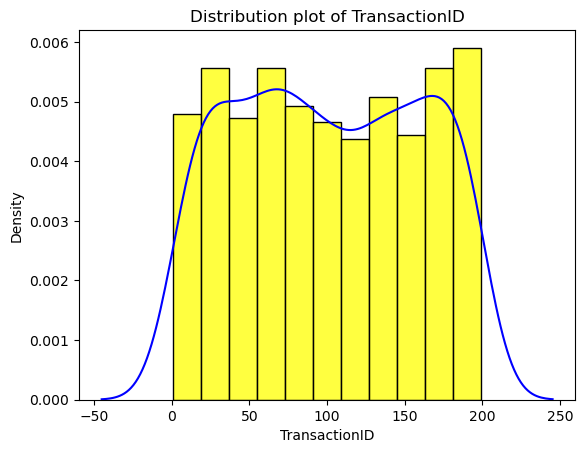

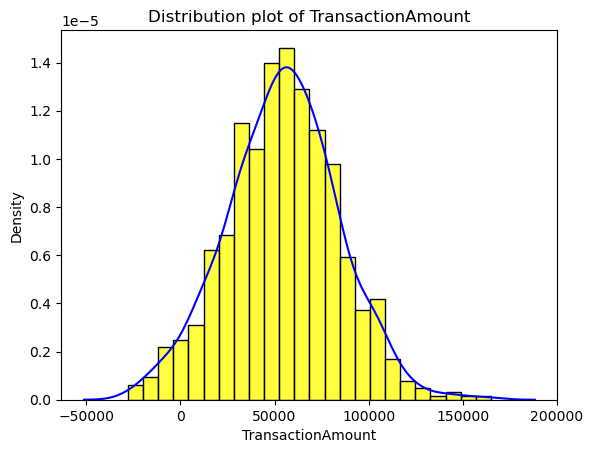

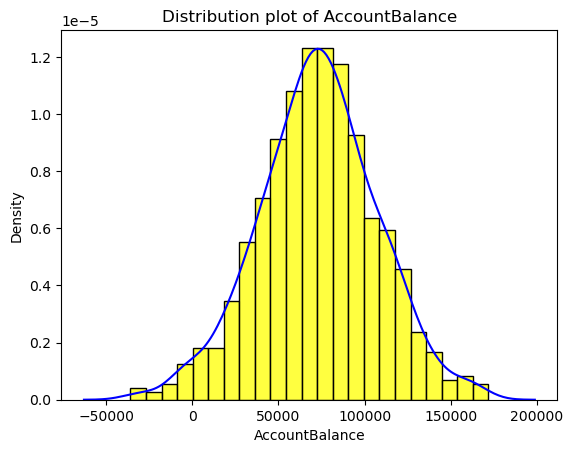

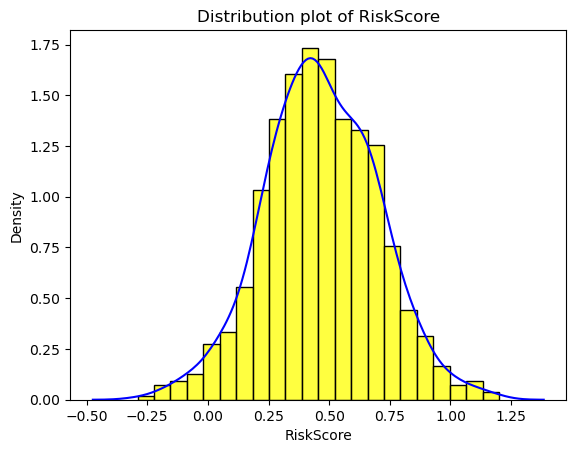

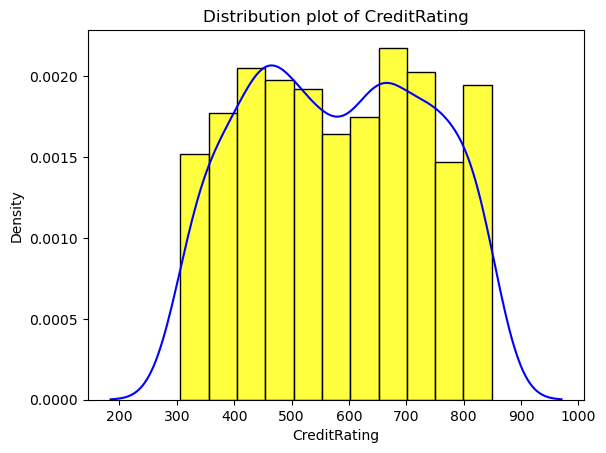

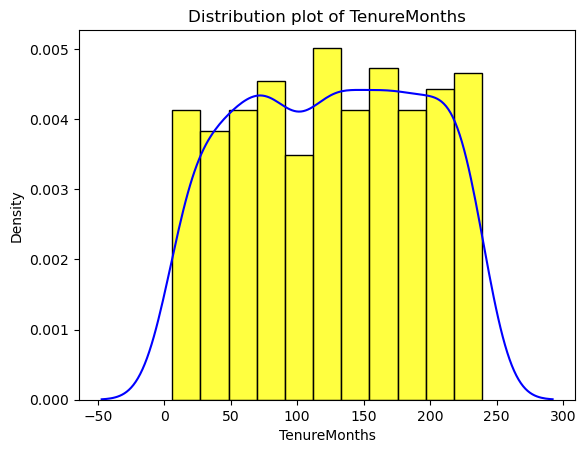

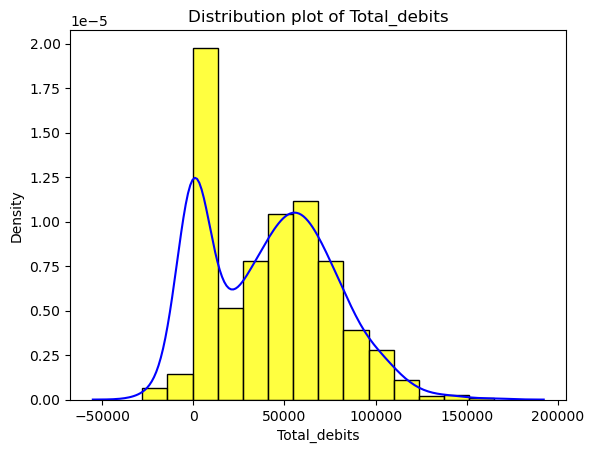

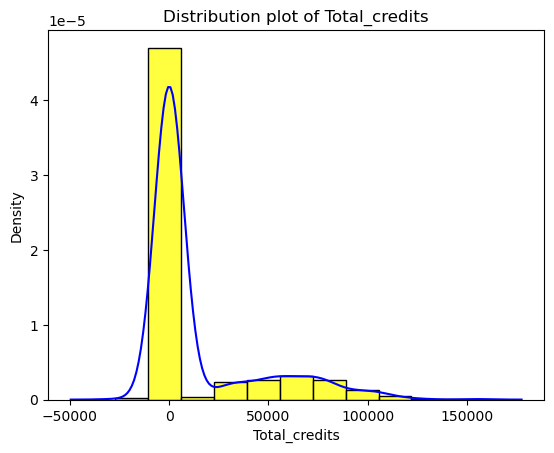

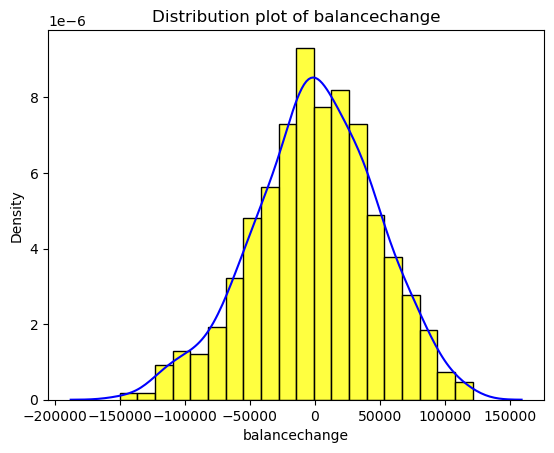

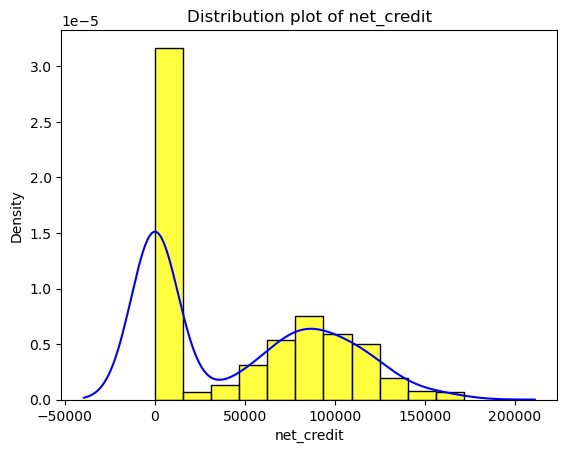

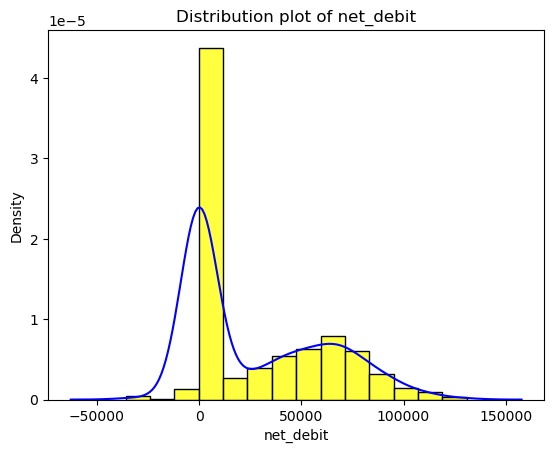

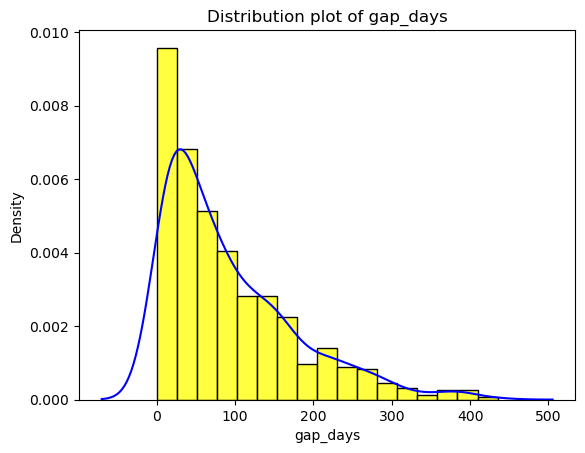

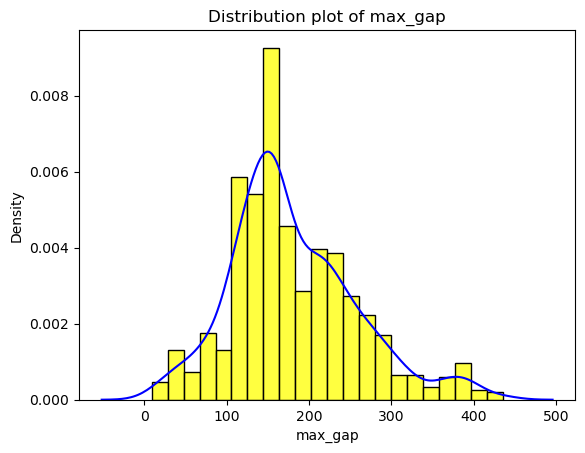

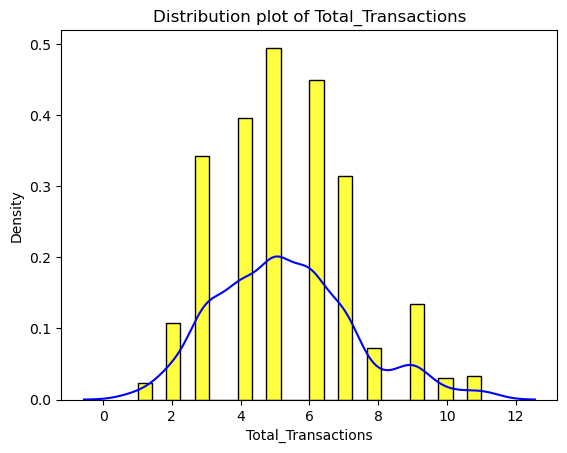

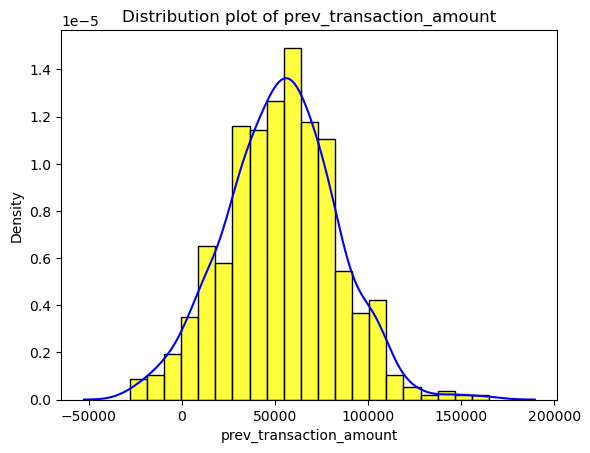

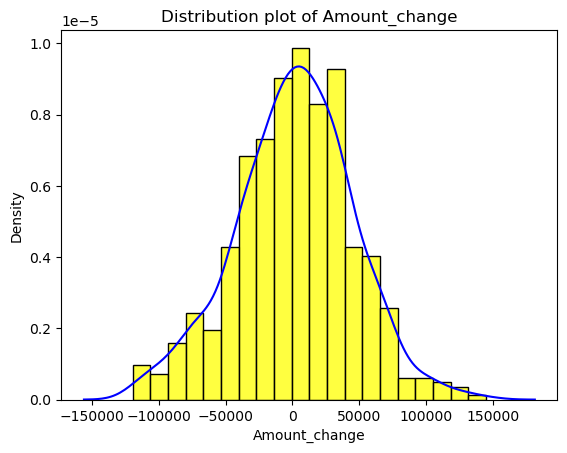

In [56]:
for col in numerical_columns:
    sns.histplot(br[col], stat= "density", color ="yellow")
    sns.kdeplot(br[col], color= "Blue", linewidth=1.5)
    plt.title(f"Distribution plot of {col}")
    plt.show()

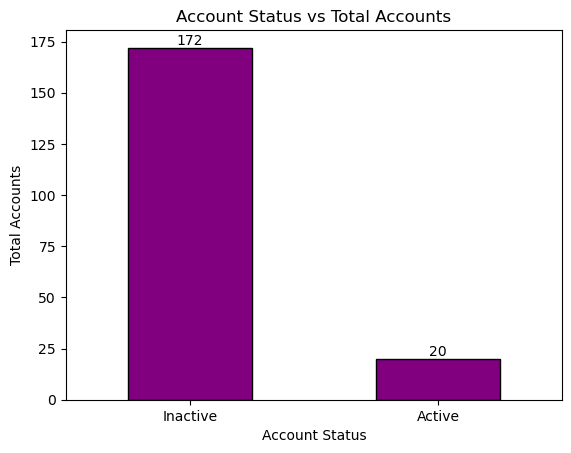

In [57]:
asplot=account_status_flag['account_status'].value_counts().plot(kind='bar',color='purple',edgecolor='black',width=0.5)
for container in asplot.containers:
    asplot.bar_label(container)
plt.title("Account Status vs Total Accounts")
plt.xlabel("Account Status")
plt.ylabel("Total Accounts")
plt.xticks(rotation=0)
plt.show()

### There are 172 out of 192 accounts that is 89.5 % accounts are Inactive rest 20 which is 10.5% of 192 are Active Accounts.

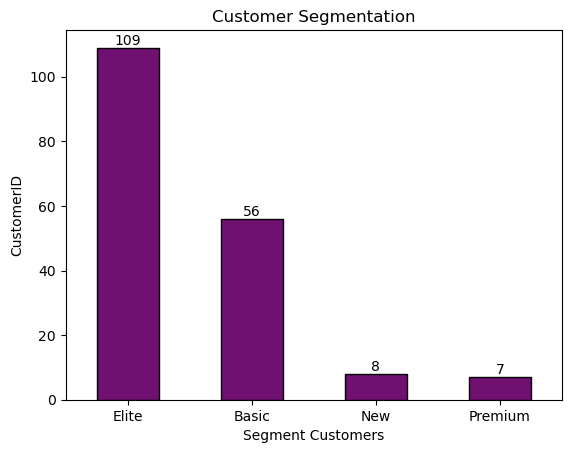

In [58]:
splot = sns.countplot(x='segment_customers', data=customer_details,color='purple',edgecolor='black',width=0.5)
for container in splot.containers:
    splot.bar_label(container)
plt.title("Customer Segmentation")
plt.xlabel("Segment Customers")
plt.ylabel("CustomerID")
plt.show()

### Out of 180 customers, 109 are Elite (high balance and moderate transactions), 56 are basic (low balance and low transactions), 8 are new customers with 1 transaction and the rest are premium customers with high balance and high transactions.

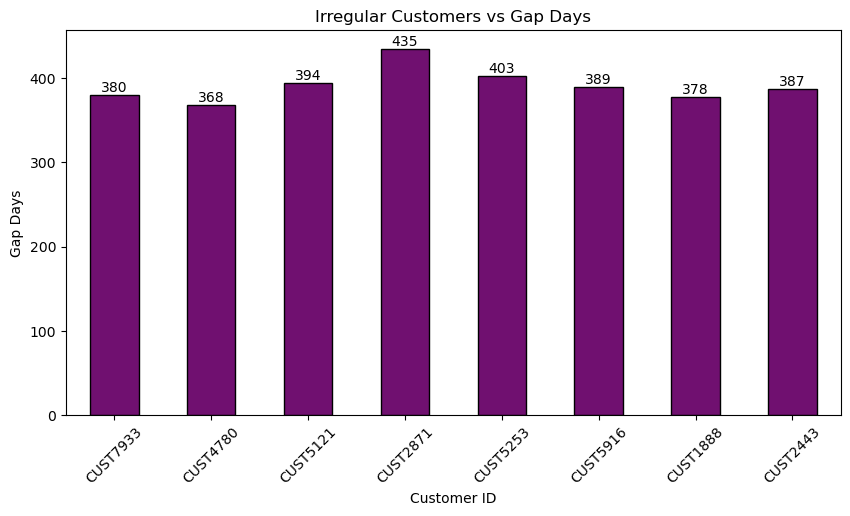

In [59]:
plt.figure(figsize=(10,5))
gdplot = sns.barplot(x='CustomerID', y='gap_days', data=irregular_customers,color='purple',edgecolor='black',width=0.5)
for container in gdplot.containers:
    gdplot.bar_label(container)
plt.xticks(rotation=45)
plt.title("Irregular Customers vs Gap Days")
plt.xlabel("Customer ID")
plt.ylabel("Gap Days")
plt.show()

### 8 out of 180 Customers have gap days between two transactions more than 365 days maximum gap day between two transaction is 435 by customerID CUST2871

In [60]:
br.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 549 to 581
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            800 non-null    int64         
 1   CustomerID               800 non-null    object        
 2   AccountID                800 non-null    object        
 3   AccountType              800 non-null    object        
 4   TransactionType          800 non-null    object        
 5   Product                  800 non-null    object        
 6   Firm                     800 non-null    object        
 7   Region                   800 non-null    object        
 8   Manager                  800 non-null    object        
 9   TransactionDate          800 non-null    datetime64[ns]
 10  TransactionAmount        800 non-null    float64       
 11  AccountBalance           800 non-null    float64       
 12  RiskScore                800 non-null  

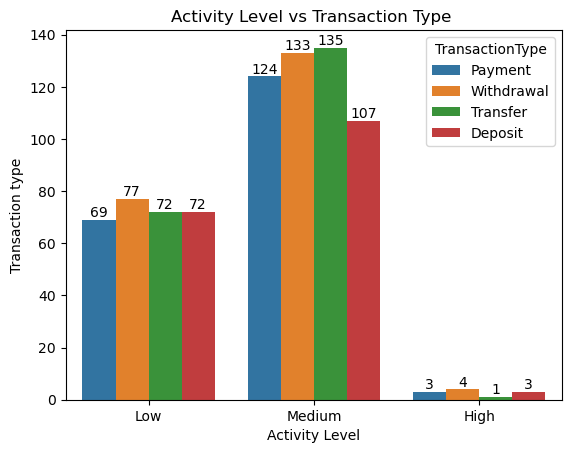

In [61]:
atplot=sns.countplot(x=br['activity_level'],hue= br['TransactionType'])
for container in atplot.containers:
    atplot.bar_label(container)
plt.title('Activity Level vs Transaction Type ')
plt.xlabel( 'Activity Level')
plt.ylabel( 'Transaction type')
plt.xticks(rotation=0)
plt.show()

### Medium activity customers are the most engaged and contribute the majority of transactions.
### Low activity users still perform all types of transactions but at a lower frequency.
### Very few customers fall into the “high activity” category.
### Transaction behavior is fairly balanced across types, with slightly higher preference for transfers and withdrawals.

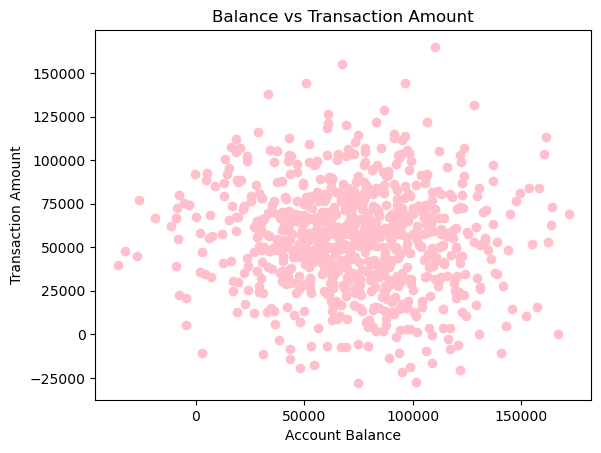

In [62]:
plt.scatter(br['AccountBalance'],br['TransactionAmount'],color='pink')
plt.xlabel("Account Balance")
plt.ylabel("Transaction Amount")
plt.title("Balance vs Transaction Amount")
plt.show()

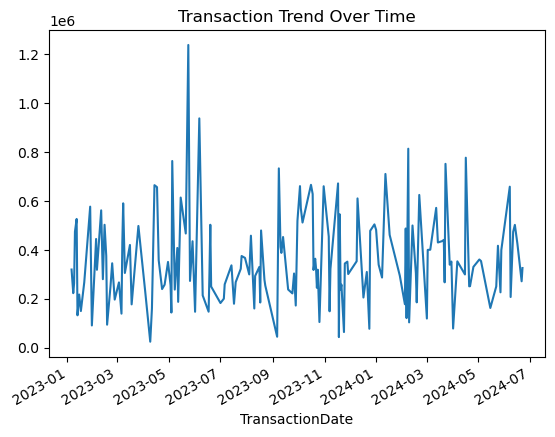

In [63]:
br.groupby('TransactionDate')['AccountBalance'].sum().plot()
plt.title("Transaction Trend Over Time")
plt.show()

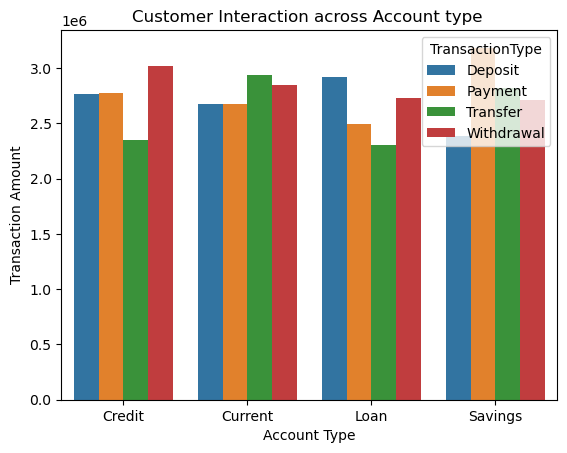

In [64]:
Customer_Interaction = br.groupby(['AccountType', 'TransactionType'])['TransactionAmount'].sum().reset_index()
sns.barplot(x='AccountType', y='TransactionAmount', hue='TransactionType', data=Customer_Interaction)
plt.title("Customer Interaction across Account type ")
plt.xlabel("Account Type")
plt.ylabel("Transaction Amount")
plt.show()

### current accounts show balanced transactions across types, while savings account vary. 
### Credit accounts have higher withdrawals than transfers, and loan accounts show higher deposits with lower debits.

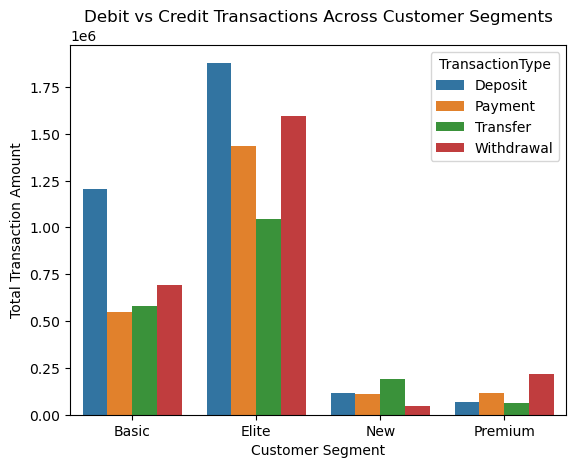

In [65]:
br['customer_segment'] = customer_details['segment_customers']
trend_summary= br.groupby(['customer_segment','TransactionType'])['TransactionAmount'].sum().reset_index()
sns.barplot(x='customer_segment', y='TransactionAmount', hue='TransactionType', data=trend_summary)
plt.title("Debit vs Credit Transactions Across Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Total Transaction Amount")
plt.show()

### Elite customers are the most financially active and high-value users.
### Basic customers have steady but moderate transaction behavior.
### New customers are still onboarding and not fully engaged yet.
### Premium users might be using accounts more for spending than saving.

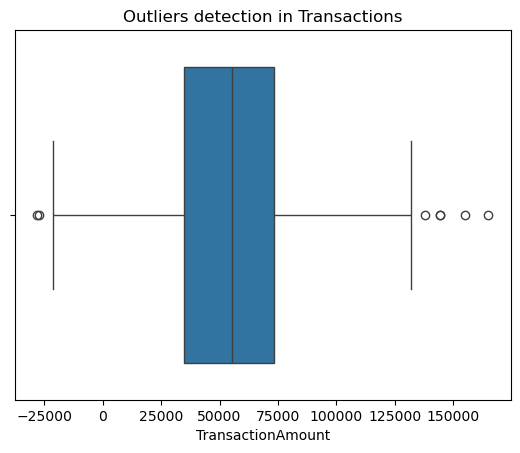

In [66]:
sns.boxplot(x=br['TransactionAmount'])
plt.title('Outliers detection in Transactions')
plt.show()

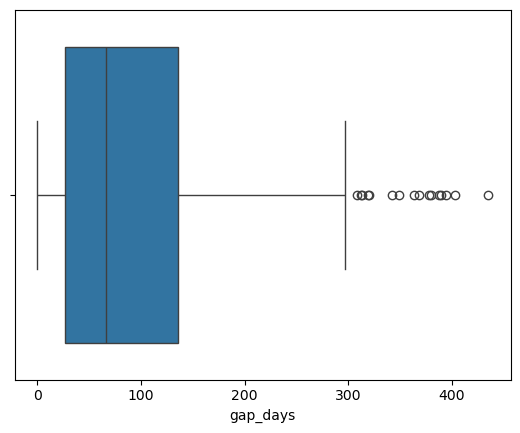

In [67]:
sns.boxplot(x=br['gap_days'])
plt.show()

# Task 6: Hypothesis Testing

### Task 6.1: Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.

#### --> null hypothesis (H0): There is no significant difference in average account balance between high-volume and low-volume accounts.
#### --> Alternate hypothesis (H1): High-volume accounts have higher average balances than low-volume accounts.

In [68]:
high_volume_account = br[br['Total_Transactions']>5]['AccountBalance']
low_volume_account = br[br['Total_Transactions']<=4]['AccountBalance']
import scipy.stats as stats
t_stat, p_value = stats.ttest_ind(high_volume_account, low_volume_account)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: 0.8093366851233071, P-value: 0.4186256180362353


#### --> From the above results it is indicated that The independent t-test produced a p-value of 0.4186, which is greater than the significance level of 0.05.
#### Therefore, we accept the null hypothesis. There is no statistically significant evidence that high-volume transaction accounts have higher average balances than low-volume accounts.

### Task 6.2 Conduct hypothesis testing based on segmentation.

### 1. Check for the relationship between net_debit and net_credit
#### --> null hypothesis (H0): There is no significant differnce between the mean value of net_debit and net_credit 
#### --> Alternative Hypothesis (H₁): There is a significant difference between the mean values of net debit and net credit transactions.we perform paired T-test 
#### --> net_debit and net_credit belongs to same accounts
#### --> Observations are paired measurements

In [69]:
import scipy.stats as stats 
t_stat, p_value = stats.ttest_rel(br['net_debit'],br['net_credit'])
print (f"T-statistic: {t_stat}. P-value: {p_value}")

T-statistic: -6.797032422130121. P-value: 2.0891367437288038e-11


#### -->The paired t-test shows a statistically significant difference between net debit and net credit transactions (p < 0.05). 
#### --> This indicates that transaction behavior differs between debit and credit activities within the same accounts.
#### --> The results suggest that credit transactions tend to be higher than debit transactions across the dataset.

### 2. To determine whether the distribution of customer status categories differs significantly from an equal distribution.
#### --> Null hypothesis (H0): Customer status category follows normal distribution.
#### --> Alternate hypothesis (H1): Customer status category does not  follows normal distribution.
#### A Chi-Square Goodness-of-Fit test was performed to compare observed frequencies of customer status with expected frequencies.

In [70]:
counts =br['account_status'].value_counts()
observed = counts.values
expected = [sum(observed)/len(observed)]*len(observed)
from scipy import stats
chi2_stat, p_value = stats.chisquare(observed,expected)
print(f"chi-square statistic: {chi2_stat}, P-value: {p_value}")

chi-square statistic: 655.22, P-value: 1.6363302545431644e-144


#### --> We reject the null hypothesis, indicating that customer account_status categories are not evenly distributed. 
#### --> This suggests that certain customer segments dominate the dataset, which may reflect behavioral or transactional differences among customers.